# Complex Systems

## Module 3: Properties of Complex Systems including Self-Organisation and Emergence


### It is to answer this question:
####    - Does the system being studied exhibit a bifurcation?
####    - Does my data exhibit complex dynamics?  And, what are the scientific and practical implications of that?




### link to dataset
https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data

### link to paper
https://www.semanticscholar.org/paper/Assessing-Beijing's-PM2.5-pollution%3A-severity%2C-APEC-Liang-Zou/8a82cccc111cbe3e7ff7bc16a3345afe8351a425

In [ ]:
# @title Import packages
import pandas as pd
from sklearn import preprocessing
import numpy as np

In [ ]:
# @title Upload file
df = pd.read_csv('/content/PRSA_data_2010.1.1-2014.12.31.csv', index_col= 'No')

In [ ]:
# @title Checking and describing columns
df.columns
'''
No:     row number
year:   year of data in this row
month:  month of data in this row
day:    day of data in this row
hour:   hour of data in this row

pm2.5:  PM2.5 concentration (ug/m^3)
        The main pollutants are fine particulate matter, and PM2.5 in particular [1,2].
        PM2.5 consists of airborne particles with aerodynamic diameters of less than 2.5 μm.
        They are known to influence visibility, human health and even climate [3].
        Epidemiological evidence shows that exposure to PM2.5 can cause lung morbidity [4],
        serious respiratory and cardiovascular diseases, and even death


        We first provide a set of descriptive statistics on the extent of the PM2.5 pollution in Beijing.
        According to the US (EPA) standard, 35 μg m−3 (the European Union uses 25 μg m−3) is the highest
        PM2.5 level for acceptable air quality, while 150 μg m−3 is widely viewed as very unhealthy and even hazardous.

        We partition the PM2.5 time series into three states: low PM state when PM2.5 ≤35 μg m−3; polluting episode
        when PM2.5>35 μg m−3; and very high PM when PM2.5>150 μg m−3.


        Wind speed is known to be influential in PM2.5 for studies on the US data

DEWP:   Dew Point (â„ƒ)
        Dew point temperature is the temperature at which air becomes fully saturated with water vapor and must cool to initiate condensation, forming dew, fog, or clouds

TEMP:   Temperature (â„ƒ)
PRES:   Pressure (hPa)
cbwd:   Combined wind direction
Iws:    Cumulated wind speed (m/s)
Is:     Cumulated hours of snow
Ir:     Cumulated hours of rain
'''

'\nNo:     row number\nyear:   year of data in this row\nmonth:  month of data in this row\nday:    day of data in this row\nhour:   hour of data in this row\n\npm2.5:  PM2.5 concentration (ug/m^3)\n        The main pollutants are fine particulate matter, and PM2.5 in particular [1,2].\n        PM2.5 consists of airborne particles with aerodynamic diameters of less than 2.5\u2009μm.\n        They are known to influence visibility, human health and even climate [3].\n        Epidemiological evidence shows that exposure to PM2.5 can cause lung morbidity [4],\n        serious respiratory and cardiovascular diseases, and even death\n\n\n        We first provide a set of descriptive statistics on the extent of the PM2.5 pollution in Beijing.\n        According to the US (EPA) standard, 35\u2009μg\u2009m−3 (the European Union uses 25\u2009μg\u2009m−3) is the highest\n        PM2.5 level for acceptable air quality, while 150\u2009μg\u2009m−3 is widely viewed as very unhealthy and even hazardo

In [ ]:
# @title Some checking data
print(df.head())

    year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
No                                                                       
1   2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
2   2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
3   2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
4   2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
5   2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0


In [ ]:
x= pd.isnull(df['year'])
x.value_counts()

,count
year,
False,43824


In [ ]:
# Checking unnormailities
df['year'].unique()
# array([2010, 2011, 2012, 2013, 2014])
m_year= pd.isnull(df['year'])
m_year.value_counts() # intact

# month
df['month'].unique()
#array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

# # hour
# df['hour'].unique()
# #array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [ ]:
# @title Target variable
df['pm2.5'].describe()

,pm2.5
count,41757.000000
mean,98.613215
std,92.050387
min,0.000000
25%,29.000000
50%,72.000000
75%,137.000000
max,994.000000


In [ ]:
# @title Replacing the missing values for pm2.5


# The values will be replaced with the linear method as it compares witht the days before and after
df['pm2.5'] = df['pm2.5'].interpolate(method='linear')

# the remaining will be replaced with the next value of the day
df['pm2.5'] = df['pm2.5'].fillna(method='bfill').fillna(method='ffill')



pm25= pd.isnull(df['pm2.5'])
pm25.value_counts()


/tmp/ipython-input-2630289208.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['pm2.5'] = df['pm2.5'].fillna(method='bfill').fillna(method='ffill')


,count
pm2.5,
False,43824


In [ ]:
# DEWP
DEWP= pd.isnull(df['DEWP'])
DEWP.value_counts()

print(df['DEWP'].describe())


count    43824.000000
mean         1.817246
std         14.433440
min        -40.000000
25%        -10.000000
50%          2.000000
75%         15.000000
max         28.000000
Name: DEWP, dtype: float64


In [ ]:
# TEMP

TEMP= pd.isnull(df['TEMP'])
TEMP.value_counts()

print(df['TEMP'].describe())



count    43824.000000
mean        12.448521
std         12.198613
min        -19.000000
25%          2.000000
50%         14.000000
75%         23.000000
max         42.000000
Name: TEMP, dtype: float64


In [ ]:
# @title  label encoding cbwd

# This is the wind-direction etc...
print(df['cbwd'].unique())

# 'NW' --> North West               0
# 'cv' --> calm and variable        1
# 'NE' --> North East               2
# 'SE' --> South East               3

['NW' 'cv' 'NE' 'SE']


In [ ]:
label_encoder = preprocessing.LabelEncoder()
label_encoder.fit(df["cbwd"])

LabelEncoder()

In [ ]:
print(list(label_encoder.classes_))
print()
print(label_encoder.transform(df["cbwd"]))

df["cbwd_encoded"] = label_encoder.transform(df["cbwd"])


df = df.drop(columns=['cbwd'])


['NE', 'NW', 'SE', 'cv']

[1 1 1 ... 1 1 1]


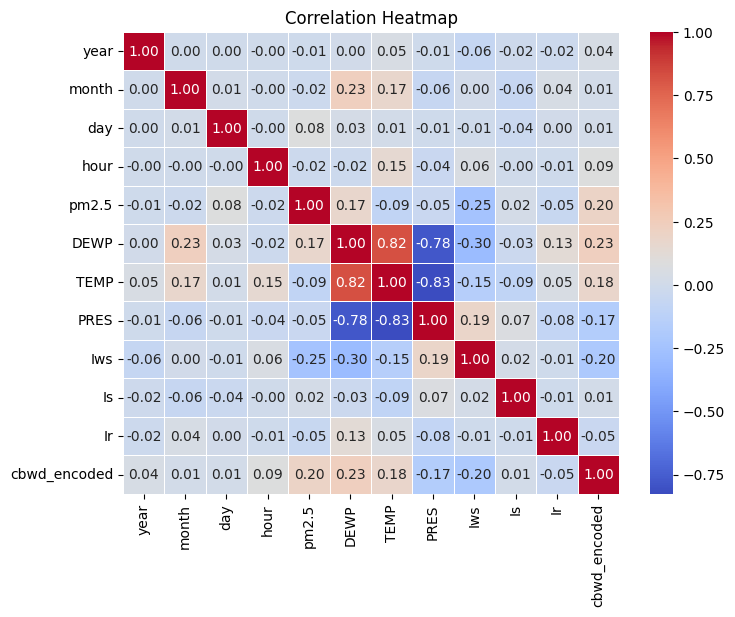

In [ ]:
# @title Correlation Matrix

import seaborn as sns
import matplotlib.pyplot as plt

matrix = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Question: Does the system being studied exhibit a bifurcation?


/tmp/ipython-input-2951817331.py:38: RuntimeWarning: overflow encountered in scalar multiply
  x = r * x * (1 - x)


Text(0, 0.5, 'x')

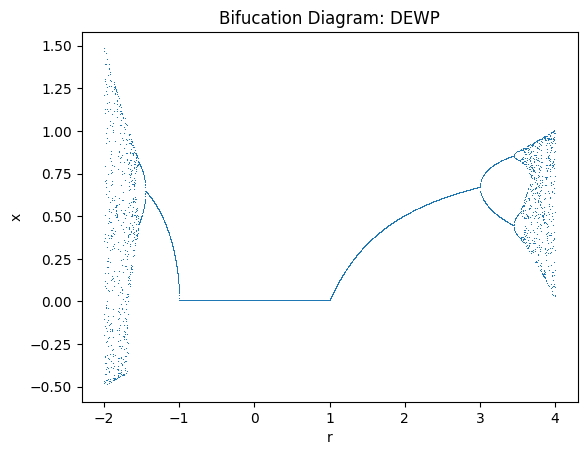

In [ ]:
# @title Bifucation map with DEMP

import random
# https://www.youtube.com/watch?v=BcVLeYV7DGQ

df['DEWP'].describe()
'''
mean	1.817246
std	14.433440
min	-40.000000
25%	-10.000000
50%	2.000000
75%	15.000000
max	28.000000
'''


# like what i see constantly now is R= np.linspace(2.5, 4, 10000)
# Determine DEWP range from dataset
dewp_min = df['DEWP'].min()
dewp_max = df['DEWP'].max()

# Generate a dense sequence of DEWP control parameter values
DEWP_r = np.linspace(dewp_min, dewp_max, 100000)  # 10000 points for smoothness

X = []
Y = []

# Generate x for each value of r

for r in DEWP_r:
  X.append(r)


  x = np.random.random()
  for n in range(100):
    x = r * x * (1 - x)

    for n in range(100):
      x = r * x * (1 - x)

  Y.append(x)

plt.plot(X, Y, ls='', marker=',')
plt.title('Bifucation Diagram: DEWP')
plt.xlabel('r')
plt.ylabel('x')

count    43824.000000
mean        98.261809
std         90.944915
min          0.000000
25%         30.000000
50%         73.000000
75%        136.000000
max        994.000000
Name: pm2.5, dtype: float64


/tmp/ipython-input-3052302986.py:39: RuntimeWarning: overflow encountered in scalar multiply
  x = r * x * (1 - x)


Text(0, 0.5, 'x')

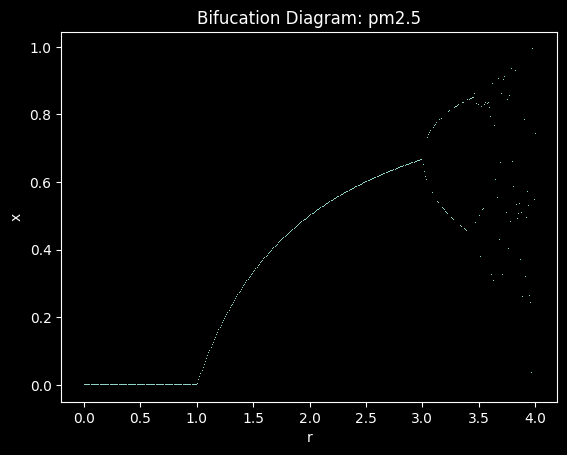

In [ ]:
# @title Bifucation map with pm2.5

import random
# https://www.youtube.com/watch?v=BcVLeYV7DGQ

print(df['pm2.5'].describe())
'''
count    43824.000000
mean        98.261809
std         90.944915
min          0.000000
25%         30.000000
50%         73.000000
75%        136.000000
max        994.000000
'''


# like what i see constantly now is R= np.linspace(2.5, 4, 10000)
# Determine pm2.5 range from dataset
pm_min = df['pm2.5'].min()
pm_max = df['pm2.5'].max()

# Generate a dense sequence of pm2.5 control parameter values
pm_r = np.linspace(pm_min, pm_max, 100000)  # 10000 points for smoothness

X = []
Y = []

# Generate x for each value of r

for r in pm_r:
  X.append(r)


  x = np.random.random()
  for n in range(100):
    x = r * x * (1 - x)

    for n in range(100):
      x = r * x * (1 - x)

  Y.append(x)

plt.plot(X, Y, ls='', marker=',')
plt.title('Bifucation Diagram: pm2.5')
plt.xlabel('r')
plt.ylabel('x')

# Henon Map

In [ ]:
df.columns

df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

In [ ]:
df['pm2.5_norm'] = (df['pm2.5'] - np.mean(df['pm2.5'])) / np.std(df['pm2.5'] )  # mean 0, std 1

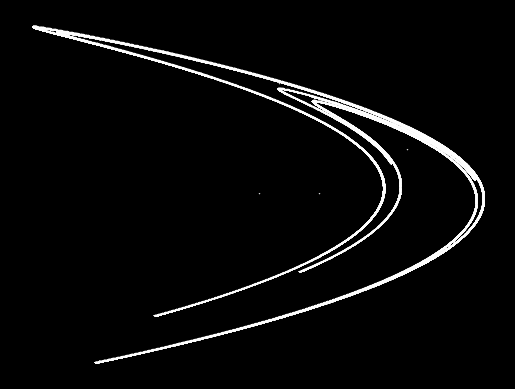

In [ ]:
# Henon graph
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')



df




def henon_attractor(x, y,a=1.4, b=0.3):
	'''Computes the next step in the Henon
	map for arguments x, y with kwargs a and
	b as constants.
	'''
	x_next = 1 - a * x ** 2 + y
	y_next = b * x
	return x_next, y_next

# number of iterations and array initialization
steps = 100000
X = np.zeros(steps + 1)
Y = np.zeros(steps + 1)

# starting point
X[0], Y[0] = df['pm2.5_norm'].iloc[0], 0

# add points to array
for i in range(steps-1):
	x_next, y_next = henon_attractor(X[i], Y[i])
	X[i+1] = x_next
	Y[i+1] = y_next

# plot figure
plt.plot(X, Y, '^', color='white', alpha = 0.8, markersize=0.3)
plt.axis('off')
plt.show()
plt.close()



/tmp/ipython-input-2830201487.py:14: RuntimeWarning: overflow encountered in scalar power
  x_next = 1 - a * x**2 + y
/tmp/ipython-input-2830201487.py:14: RuntimeWarning: overflow encountered in scalar multiply
  x_next = 1 - a * x**2 + y


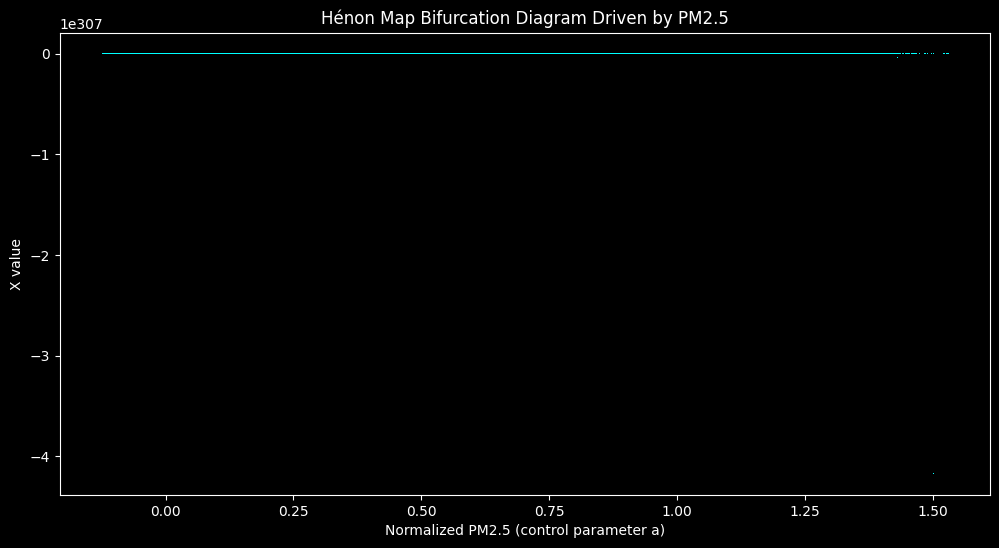

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# --- Normalize PM2.5 to 0 mean, std 1 ---
df['pm2.5_norm'] = (df['pm2.5'] - df['pm2.5'].mean()) / df['pm2.5'].std()

# --- Hénon map function ---
def henon(x, y, a, b=0.3):
    x_next = 1 - a * x**2 + y
    y_next = b * x
    return x_next, y_next

# --- Bifurcation diagram ---
b = 0.3
n_iter = 200
n_last = 100

# Use PM2.5 values as "a" control parameter
# Downsample to 5000 points for speed
pm_values = np.linspace(df['pm2.5_norm'].min(), df['pm2.5_norm'].max(), 5000)

X = []
A = []

for a in pm_values:
    x, y = 0, 0  # initial condition
    # skip transients
    for i in range(n_iter - n_last):
        x, y = henon(x, y, a, b)
    # collect last iterations
    for i in range(n_last):
        x, y = henon(x, y, a, b)
        X.append(x)
        A.append(a)

# --- Plot ---
plt.figure(figsize=(12,6))
plt.plot(A, X, ls='', marker=',', color='cyan')
plt.xlabel('Normalized PM2.5 (control parameter a)')
plt.ylabel('X value')
plt.title('Hénon Map Bifurcation Diagram Driven by PM2.5')
plt.show()

 # Question: Does my data exhibit complex dynamics? And, what are the scientific and practical implications of that?


In [ ]:
df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'],day=df['day'] ))
df = df.sort_values('date')


In [ ]:
df['date_monthly'] = pd.to_datetime(dict(year=df['year'], month=df['month'],day=df['day'] ))


# Checking out for some ideas

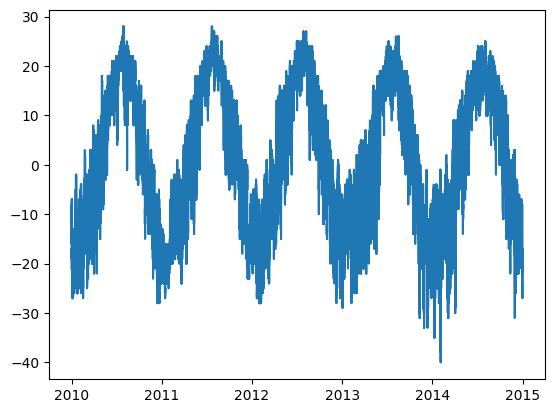

In [ ]:
df.columns
plt.plot(df['date_monthly'], df['DEWP'])

In [ ]:
df.columns

Index(['year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws',
       'Is', 'Ir', 'cbwd_encoded', 'date', 'date_monthlyu', 'date_monthlyy',
       'date_monthly'],
      dtype='object')

In [ ]:
df['pm2.5'].describe()

,pm2.5
count,43824.000000
mean,98.261809
std,90.944915
min,0.000000
25%,30.000000
50%,73.000000
75%,136.000000
max,994.000000


# Idea with the implementation of the context of properties of dynamical systems, to check out the development of pm2.5 of the years.

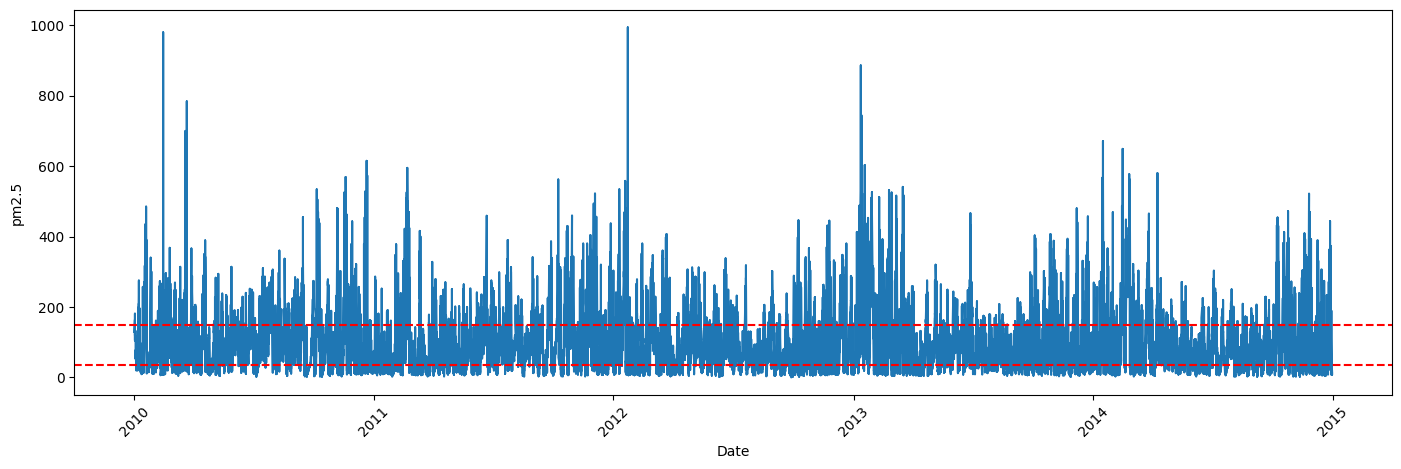

In [ ]:

df.columns

plt.figure(figsize=(17,5))
plt.plot(df['date_monthly'], df['pm2.5'])
plt.xlabel("Date")
plt.ylabel("pm2.5")
plt.axhline(y=35, linestyle='--', color='red')
plt.axhline(y=150, linestyle='--', color='red')
plt.xticks(rotation=45)
plt.show()

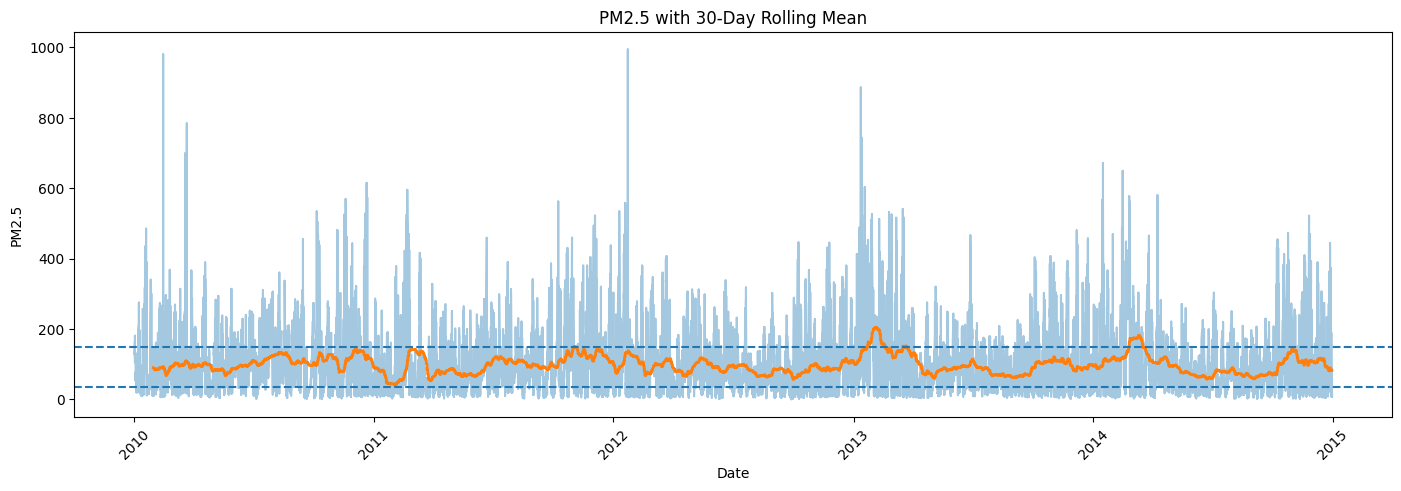

In [ ]:


# 30-day rolling mean (hourly data → 720 hours)
rolling_mean = df['pm2.5'].rolling(window=720).mean()

plt.figure(figsize=(17,5))
plt.plot(df['date_monthly'], df['pm2.5'], alpha=0.4)
plt.plot(df['date_monthly'], rolling_mean, linewidth=2)

plt.axhline(35, linestyle='--')
plt.axhline(150, linestyle='--')

plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.title("PM2.5 with 30-Day Rolling Mean")
plt.xticks(rotation=45)
plt.show()


# Observation
- 2011 January
- 2013 January
- 2014 January

Remarkable changes and differences.

<Figure size 1000x500 with 0 Axes>

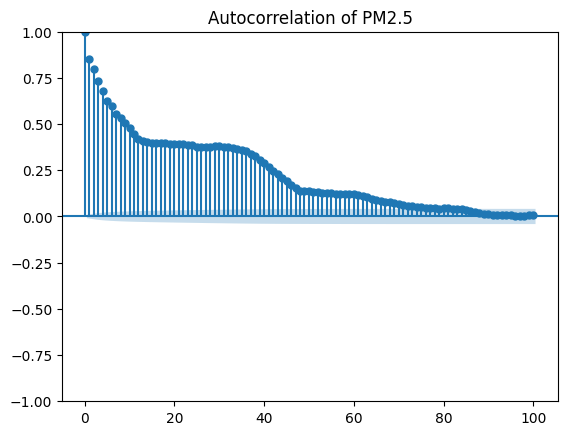

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))
plot_acf(df['pm2.5'].dropna(), lags=100)
plt.title("Autocorrelation of PM2.5")
plt.show()


This plot shows the decrease of the days that impact the next day for the pm2.5.
So for instance, like a day after has a lot of impact on the next dat, and then when you look at day 100, the impact is minimal to none.

It gradually decreases as well, which is means it is a trend. If it spikes, there might be a seasonal trend or something else.

# Checking out why there are spikes in the days i have mentioned before with a correlation map.

In [ ]:
jan_2011 = df[(df['year'] == 2011) & (df['month'] == 1)]
# jan_2011['pm2.5'].describe()

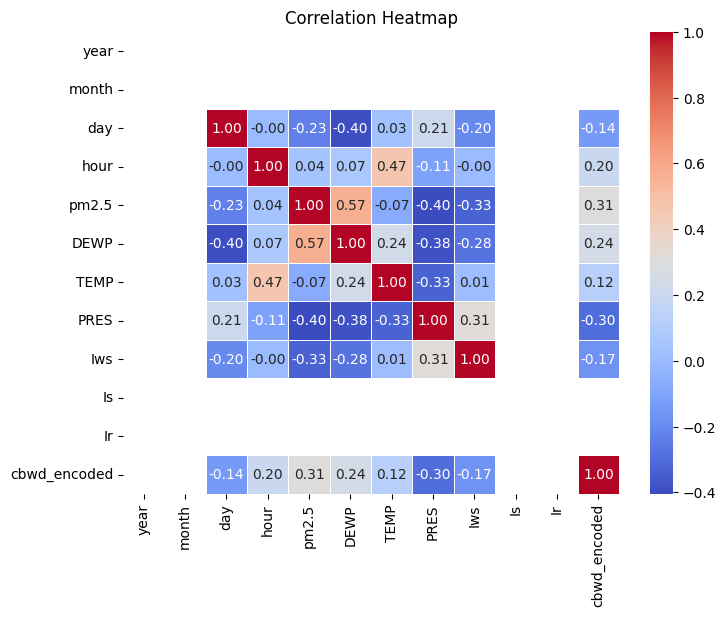

In [ ]:



matrix = jan_2011.select_dtypes(include='number').corr()


plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
jan_2013 = df[(df['year'] == 2013) & (df['month'] == 1)]
jan_2013['pm2.5'].describe()

,pm2.5
count,744.000000
mean,193.876344
std,168.926601
min,7.000000
25%,46.000000
50%,150.000000
75%,311.250000
max,886.000000


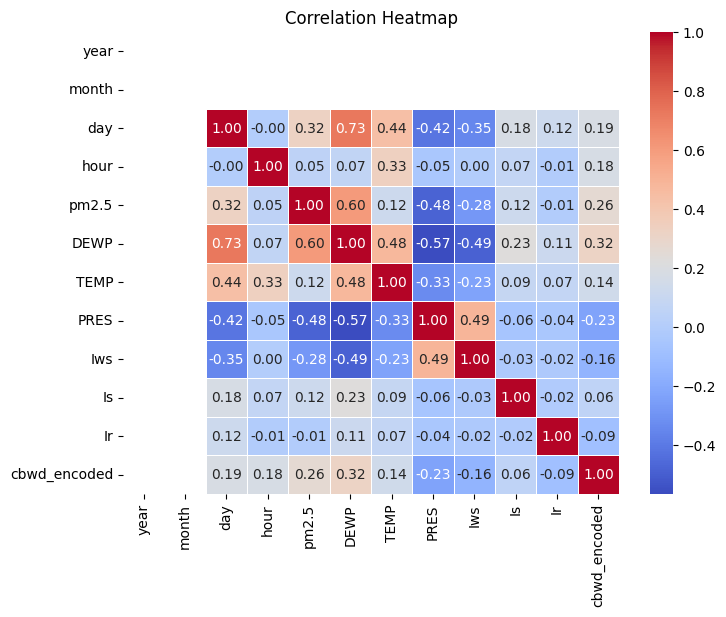

In [ ]:

matrix = jan_2013.select_dtypes(include='number').corr()


plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
jan_2014 = df[(df['year'] == 2014) & (df['month'] == 2)]
jan_2014['pm2.5'].describe()

,pm2.5
count,672.000000
mean,174.665179
std,145.128352
min,3.000000
25%,54.000000
50%,134.000000
75%,282.250000
max,649.000000


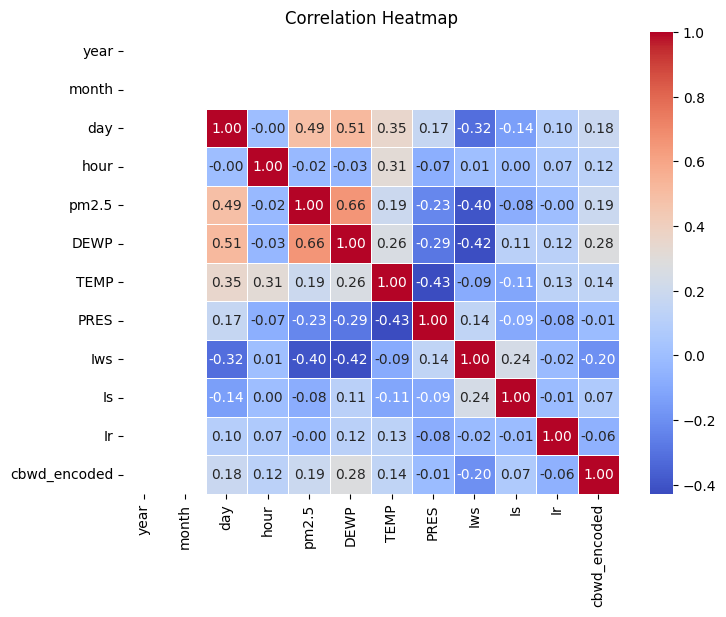

In [ ]:

matrix = jan_2014.select_dtypes(include='number').corr()


plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

You can see that the variables that impacted the pm2.5 varies from time to time.